In [1]:
%pylab inline

import jax
import jax.numpy as jnp
import tensorflow_probability as tfp; tfp = tfp.substrates.jax
tfd = tfp.distributions
tfb = tfp.bijectors

from jaxlie import SO3
from so3dm.distributions.isotropic_gaussian import IsotropicGaussianSO3
from so3dm.plotting import visualize_so3_probabilities

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


## Defining our toy distribution

In [2]:
def make_dist(sigma=0.):
  """
  Returns a mixture of Gaussians, convolved with a Gaussian of specified sigma
  """
  d1 = IsotropicGaussianSO3(SO3.identity(), jnp.sqrt(0.1**2+sigma**2))
  d2 = IsotropicGaussianSO3(SO3.from_z_radians(pi), jnp.sqrt(0.1**2+sigma**2))
  return d1,d2

/home/francois/repo/SO3DiffusionModels/so3dm/plotting.py:98: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels([r'90$\degree$', None,


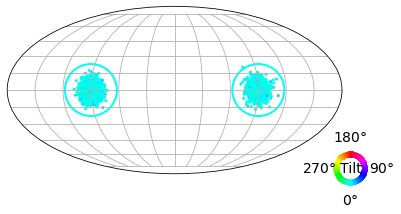

In [3]:
# At zero temperature
d1,d2 = make_dist(0.)
samples = jnp.concatenate([d2.sample(1024, seed=jax.random.PRNGKey(1)), 
                           d1.sample(1024, seed=jax.random.PRNGKey(0))])

visualize_so3_probabilities(
    jax.vmap(lambda x: SO3(x).as_matrix())(samples),
    0.001,
    rotations_gt=jnp.stack([d1._loc.as_matrix(), d2._loc.as_matrix()], axis=0) );

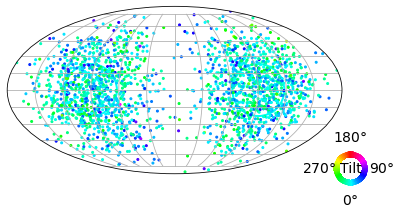

In [4]:
# At some non zero temperature
d1,d2 = make_dist(0.5)
samples = jnp.concatenate([d2.sample(1024, seed=jax.random.PRNGKey(1)), 
                           d1.sample(1024, seed=jax.random.PRNGKey(0))])

visualize_so3_probabilities(
    jax.vmap(lambda x: SO3(x).as_matrix())(samples),
    0.001,
    rotations_gt=jnp.stack([d1._loc.as_matrix(), d2._loc.as_matrix()], axis=0) );

## Defining our SDE

We are going to solve the sampling by 

$$\mathrm{d}x = [ f(x,t) - \frac{1}{2} g(t)^2 \nabla_x \log p_t(x)] \mathrm{d}t$$

We just need to know what the drift function $f$ and diffusion function $g$ are in our case.

So, in Denoising score matching with Langevin Dynamics(SMLD), we have:
$$ f = 0  \ \mbox{and} \  g(t) = \sqrt{\frac{d \sigma^2(t)}{dt}}$$

So... I guess we can choose $\sigma^2(t) = t$ so that $g(t) = 1$.


In that simple case, our ODE becomes:

$$\mathrm{d}x = - \frac{1}{2} \nabla_x \log p_t(x) \mathrm{d}t$$

In [240]:
def make_dist(sigma=0.):
  """
  Returns a mixture of Gaussians, convolved with a Gaussian of specified sigma
  """
  return IsotropicGaussianSO3(SO3.from_x_radians(pi), jnp.sqrt(0.1**2+sigma**2))

In [241]:
import functools

@functools.partial(jax.vmap, in_axes=[0, None])
def score_fn(x,t):
  def fn(s):
    return make_dist(jnp.sqrt(t)).log_prob( (SO3.exp(x) @ SO3.exp(s)).wxyz )
  return jax.grad(fn)(jnp.zeros(3))

In [242]:
from scipy import integrate

In [243]:
start_and_end_times = jnp.linspace(1.,0)

points = make_dist(sigma=1.).sample(2048, seed=jax.random.PRNGKey(42))
aa = jax.vmap(lambda x: SO3(x).log())(points)

@jax.jit
def dynamics(t, x):
  x = x.reshape([-1,3])
  return - 0.5*score_fn(x,t).flatten()

solution = integrate.solve_ivp(dynamics, 
                               [1.,0.],
                               aa.flatten(),
                               t_eval=start_and_end_times
                               )

In [244]:
solution

  message: 'Required step size is less than spacing between numbers.'
     nfev: 578
     njev: 0
      nlu: 0
      sol: None
   status: -1
  success: False
        t: array([1.        , 0.97959185, 0.9591837 , 0.93877554, 0.9183673 ,
       0.8979592 , 0.877551  , 0.85714287, 0.8367347 , 0.8163265 ,
       0.79591835, 0.7755102 , 0.75510204, 0.7346939 , 0.71428573,
       0.6938776 , 0.6734694 , 0.6530613 , 0.63265306, 0.6122449 ,
       0.59183675, 0.57142854, 0.5510204 , 0.53061223, 0.5102041 ,
       0.48979592, 0.46938777, 0.44897962, 0.42857146, 0.40816325,
       0.3877551 , 0.36734694, 0.3469388 , 0.32653064, 0.30612248,
       0.28571433, 0.26530612, 0.24489796, 0.22448981, 0.20408165,
       0.1836735 , 0.16326535, 0.14285713, 0.12244898, 0.10204083,
       0.08163267, 0.06122452], dtype=float32)
 t_events: None
        y: array([[-2.90251017, -2.90383341, -2.90517572, ..., -2.99643757,
        -3.00121243, -3.00658208],
       [ 0.75840896,  0.7579246 ,  0.75739791, ...,  0

/tmp/ipykernel_61534/302624203.py:93: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  ax.pcolormesh(theta, radii, colormap_val.T, cmap=cmap)
/tmp/ipykernel_61534/302624203.py:95: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels([r'90$\degree$', None,


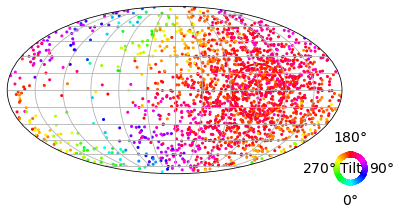

In [245]:
visualize_so3_probabilities(
    jax.vmap(lambda x: SO3.exp(x).as_matrix())(solution.y[:,-1].reshape([-1,3])),
    0.001,
    rotations_gt=make_dist()._loc.as_matrix());

In [246]:
# The following is borrowed from https://github.com/ericjang/nf-jax/blob/master/nf-tutorial-jax.ipynb
from matplotlib import animation, rc
# from IPython.display import HTML, Image
# equivalent to rcParams['animation.html'] = 'html5'
rc('animation', html='html5')

In [247]:
def visualize_so3_probabilities(rotations,
                                probabilities,
                                rotations_gt=None,
                                ax=None,
                                fig=None,
                                paths=None,
                                show_color_wheel=True,
                                canonical_rotation=np.eye(3)):
  """Plot a single distribution on SO(3) using the tilt-colored method.

  Args:
    rotations: [N, 3, 3] tensor of rotation matrices
    probabilities: [N] tensor of probabilities
    rotations_gt: [N_gt, 3, 3] or [3, 3] ground truth rotation matrices
    ax: The matplotlib.pyplot.axis object to paint
    fig: The matplotlib.pyplot.figure object to paint
    show_color_wheel: If True, display the explanatory color wheel which matches
      color on the plot with tilt angle
    canonical_rotation: A [3, 3] rotation matrix representing the 'display
      rotation', to change the view of the distribution.  It rotates the
      canonical axes so that the view of SO(3) on the plot is different, which
      can help obtain a more informative view.
  Returns:
    A matplotlib.pyplot.figure object, or a tensor of pixels if to_image=True.
  """
  def _show_single_marker(ax, rotation, marker, edgecolors=True,
                          facecolors=False):
    eulers = SO3.from_matrix(rotation).as_rpy_radians()
    xyz = rotation[:, 0]
    tilt_angle = eulers[0]
    longitude = np.arctan2(xyz[0], -xyz[1])
    latitude = np.arcsin(xyz[2])

    color = cmap(0.5 + tilt_angle / 2 / np.pi)
    ax.scatter(longitude, latitude, s=2500,
               edgecolors=color if edgecolors else 'none',
               facecolors=facecolors if facecolors else 'none',
               marker=marker,
               linewidth=4)

  if ax is None:
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='mollweide')
  if rotations_gt is not None and len(rotations_gt.shape) == 2:
    rotations_gt = jnp.expand_dims(rotations_gt,axis=0)

  display_rotations = rotations @ canonical_rotation
  cmap = plt.cm.hsv
  scatterpoint_scaling = 4e3
  eulers_queries = jax.vmap(lambda x: SO3.from_matrix(x).as_rpy_radians())(display_rotations)
  xyz = display_rotations[:, :, 0]
  tilt_angles = eulers_queries.roll

  longitudes = np.arctan2(xyz[:, 0], -xyz[:, 1])
  latitudes = np.arcsin(xyz[:, 2])
  if paths is not None:
    paths.set_offsets(np.stack([longitudes, latitudes], axis=-1))
    paths.set_color(cmap(0.5 + tilt_angles / 2. / np.pi))
    return paths
    
#   which_to_display = (probabilities > display_threshold_probability)

  if rotations_gt is not None:
    # The visualization is more comprehensible if the GT
    # rotation markers are behind the output with white filling the interior.
    display_rotations_gt = rotations_gt @ canonical_rotation

    for rotation in display_rotations_gt:
      _show_single_marker(ax, rotation, 'o')
    # Cover up the centers with white markers
    for rotation in display_rotations_gt:
      _show_single_marker(ax, rotation, 'o', edgecolors=False,
                          facecolors='#ffffff')

  # Display the distribution
  paths = ax.scatter(
      longitudes,
      latitudes,
      s=scatterpoint_scaling * probabilities,
      c=cmap(0.5 + tilt_angles / 2. / np.pi))

  ax.grid()
  ax.set_xticklabels([])
  ax.set_yticklabels([])

  if show_color_wheel:
    # Add a color wheel showing the tilt angle to color conversion.
    ax = fig.add_axes([0.86, 0.17, 0.12, 0.12], projection='polar')
    theta = np.linspace(-3 * np.pi / 2, np.pi / 2, 200)
    radii = np.linspace(0.4, 0.5, 2)
    _, theta_grid = np.meshgrid(radii, theta)
    colormap_val = 0.5 + theta_grid / np.pi / 2.
    ax.pcolormesh(theta, radii, colormap_val.T, cmap=cmap)
    ax.set_yticklabels([])
    ax.set_xticklabels([r'90$\degree$', None,
                        r'180$\degree$', None,
                        r'270$\degree$', None,
                        r'0$\degree$'], fontsize=14)
    ax.spines['polar'].set_visible(False)
    plt.text(0.5, 0.5, 'Tilt', fontsize=14,
             horizontalalignment='center',
             verticalalignment='center', transform=ax.transAxes)
  return paths

/tmp/ipykernel_61534/302624203.py:93: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  ax.pcolormesh(theta, radii, colormap_val.T, cmap=cmap)
/tmp/ipykernel_61534/302624203.py:95: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels([r'90$\degree$', None,


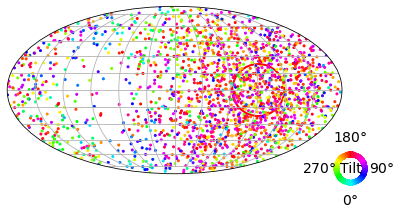

In [248]:
fig = plt.figure()
ax = fig.add_subplot( projection='mollweide')

paths = visualize_so3_probabilities(
    jax.vmap(lambda x: SO3.exp(x).as_matrix())(solution.y[:,0].reshape([-1,3])),
    0.001,
    fig=fig,
    ax=ax,
    rotations_gt=make_dist()._loc.as_matrix())

def animate(i):
  visualize_so3_probabilities(
    jax.vmap(lambda x: SO3.exp(x).as_matrix())(solution.y[:,min(i,46)].reshape([-1,3])),
    0.001,
    fig=fig,
    ax=ax,
    paths=paths,
    rotations_gt=make_dist()._loc.as_matrix())
  return (paths,)

anim = animation.FuncAnimation(fig, animate, frames=70, interval=100, blit=False)

In [249]:
anim

In [169]:
anim

In [192]:
# Now let's check the distribution of these points
from so3dm.distributions.isotropic_gaussian import _isotropic_gaussian_so3_small, _isotropic_gaussian_so3

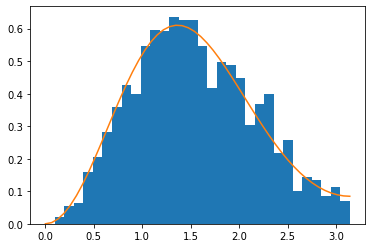

In [194]:
theta = jnp.linspace(0, pi)
angles = jnp.linalg.norm(solution.y[:,0].reshape([-1,3]),axis=-1)

hist(angles,32, density=True, range=[0,pi]);

plot(theta, (1 - cos(theta))/pi*_isotropic_gaussian_so3(theta, jnp.sqrt(0.1**2+1**2)/jnp.sqrt(2)))

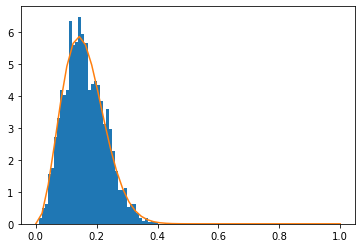

In [195]:
theta = jnp.linspace(0, 1)
angles = jnp.linalg.norm(solution.y[:,-1].reshape([-1,3]),axis=-1)

hist(angles,100, density=True, range=[0,1]);
plot(theta, (1 - cos(theta))/pi*_isotropic_gaussian_so3_small(theta, 0.1/jnp.sqrt(2)))

## Now let's try a multimodal distribution

In [199]:
def make_dist(sigma=0.):
  """
  Returns a mixture of Gaussians, convolved with a Gaussian of specified sigma
  """
  d1 = IsotropicGaussianSO3(SO3.identity(), jnp.sqrt(0.1**2+sigma**2))
  d2 = IsotropicGaussianSO3(SO3.from_z_radians(pi), jnp.sqrt(0.1**2+sigma**2))
  return d1,d2

import functools
@functools.partial(jax.vmap, in_axes=[0, None])
def score_fn(x,t):
  def fn(s):
    d1,d2= make_dist(jnp.sqrt(t))
    y = (SO3.exp(x) @ SO3.exp(s)).wxyz
    return d1.log_prob(y) + d2.log_prob(y)  
  return jax.grad(fn)(jnp.zeros(3))

In [204]:
start_and_end_times = jnp.linspace(1.,0)


d1,d2 = make_dist(1.)
points = jnp.concatenate([d2.sample(1024, seed=jax.random.PRNGKey(1)), 
                           d1.sample(1024, seed=jax.random.PRNGKey(0))])
aa = jax.vmap(lambda x: SO3(x).log())(points)

@jax.jit
def dynamics(t, x):
  x = x.reshape([-1,3])
  return - 0.5*score_fn(x,t).flatten()

solution = integrate.solve_ivp(dynamics, 
                               [1.,0.],
                               aa.flatten(),
                               t_eval=start_and_end_times
                               )

In [205]:
solution

  message: 'Required step size is less than spacing between numbers.'
     nfev: 590
     njev: 0
      nlu: 0
      sol: None
   status: -1
  success: False
        t: array([1.        , 0.97959185, 0.9591837 , 0.93877554, 0.9183673 ,
       0.8979592 , 0.877551  , 0.85714287, 0.8367347 , 0.8163265 ,
       0.79591835, 0.7755102 , 0.75510204, 0.7346939 , 0.71428573,
       0.6938776 , 0.6734694 , 0.6530613 , 0.63265306, 0.6122449 ,
       0.59183675, 0.57142854, 0.5510204 , 0.53061223, 0.5102041 ,
       0.48979592, 0.46938777, 0.44897962, 0.42857146, 0.40816325,
       0.3877551 , 0.36734694, 0.3469388 , 0.32653064, 0.30612248,
       0.28571433, 0.26530612, 0.24489796, 0.22448981, 0.20408165,
       0.1836735 , 0.16326535, 0.14285713, 0.12244898, 0.10204083,
       0.08163267, 0.06122452, 0.04081637, 0.02040815], dtype=float32)
 t_events: None
        y: array([[-0.62691754, -0.61869875, -0.61033936, ...,  0.02063081,
         0.04363793,  0.0626615 ],
       [ 0.26148835,  0.264778

/tmp/ipykernel_61534/302624203.py:93: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  ax.pcolormesh(theta, radii, colormap_val.T, cmap=cmap)
/tmp/ipykernel_61534/302624203.py:95: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels([r'90$\degree$', None,


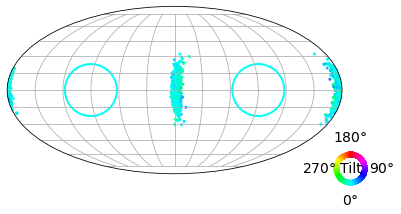

In [208]:
visualize_so3_probabilities(
    jax.vmap(lambda x: SO3.exp(x).as_matrix())(solution.y[:,-1].reshape([-1,3])),
    0.001,
    rotations_gt=jnp.stack([d1._loc.as_matrix(), d2._loc.as_matrix()], axis=0) );

/tmp/ipykernel_61534/302624203.py:93: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  ax.pcolormesh(theta, radii, colormap_val.T, cmap=cmap)
/tmp/ipykernel_61534/302624203.py:95: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels([r'90$\degree$', None,


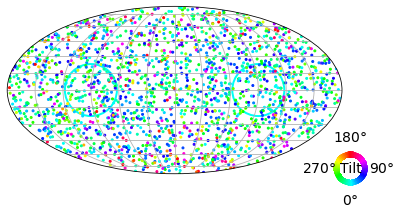

In [212]:
fig = plt.figure()
ax = fig.add_subplot( projection='mollweide')

paths = visualize_so3_probabilities(
    jax.vmap(lambda x: SO3.exp(x).as_matrix())(solution.y[:,0].reshape([-1,3])),
    0.001,
    fig=fig,
    ax=ax,
    rotations_gt=jnp.stack([d1._loc.as_matrix(), d2._loc.as_matrix()], axis=0))

def animate(i):
  visualize_so3_probabilities(
    jax.vmap(lambda x: SO3.exp(x).as_matrix())(solution.y[:,min(i,48)].reshape([-1,3])),
    0.001,
    fig=fig,
    ax=ax,
    paths=paths,
    rotations_gt=jnp.stack([d1._loc.as_matrix(), d2._loc.as_matrix()], axis=0))
  return (paths,)

anim = animation.FuncAnimation(fig, animate, frames=70, interval=100, blit=False)

In [213]:
anim